In [7]:
!pip install tensorflow 
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.datasets import cifar10

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 26.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 37.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 49.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 73.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.4
    Uninstalling numpy-2.2.4:
      Successfully uninstalled numpy-2.2.4

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


2025-05-19 12:07:35.988905: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-19 12:07:36.007667: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-19 12:07:36.201311: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-19 12:07:36.327663: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747656456.526762   16472 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747656456.57

In [8]:
def create_model_v1():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        MaxPooling2D((2,2)),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [9]:
def create_model_v2():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        MaxPooling2D((2,2)),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.0008), loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [10]:
def create_model_v3():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        Conv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.3),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [12]:
# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
print(X_train.shape, X_test.shape)  # (50000, 32, 32, 3) (10000, 32, 32, 3)
# Normalize pixel values to range [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
# Convert class labels to one-hot encoded vectors
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)
# Split the training data into training and validation sets (80/20 split)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
(50000, 32, 32, 3) (10000, 32, 32, 3)


In [13]:
# Setup early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train models
model1 = create_model_v1()
history1 = model1.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=64, callbacks=[early_stop])

model2 = create_model_v2()
history2 = model2.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=64, callbacks=[early_stop])

model3 = create_model_v3()
history3 = model3.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=64, callbacks=[early_stop])


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 54ms/step - accuracy: 0.3012 - loss: 1.8890 - val_accuracy: 0.5453 - val_loss: 1.2498
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 50ms/step - accuracy: 0.5433 - loss: 1.2709 - val_accuracy: 0.6330 - val_loss: 1.0169
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.6257 - loss: 1.0505 - val_accuracy: 0.6668 - val_loss: 0.9488
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.6729 - loss: 0.9346 - val_accuracy: 0.6873 - val_loss: 0.8736
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.7015 - loss: 0.8390 - val_accuracy: 0.7191 - val_loss: 0.8052
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.7284 - loss: 0.7646 - val_accuracy: 0.7250 - val_loss: 0.7830
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.7550 - loss: 0.7021 - val_accuracy: 0.7270 - val_loss: 0.7907
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.7736 - loss: 0.6419 - 

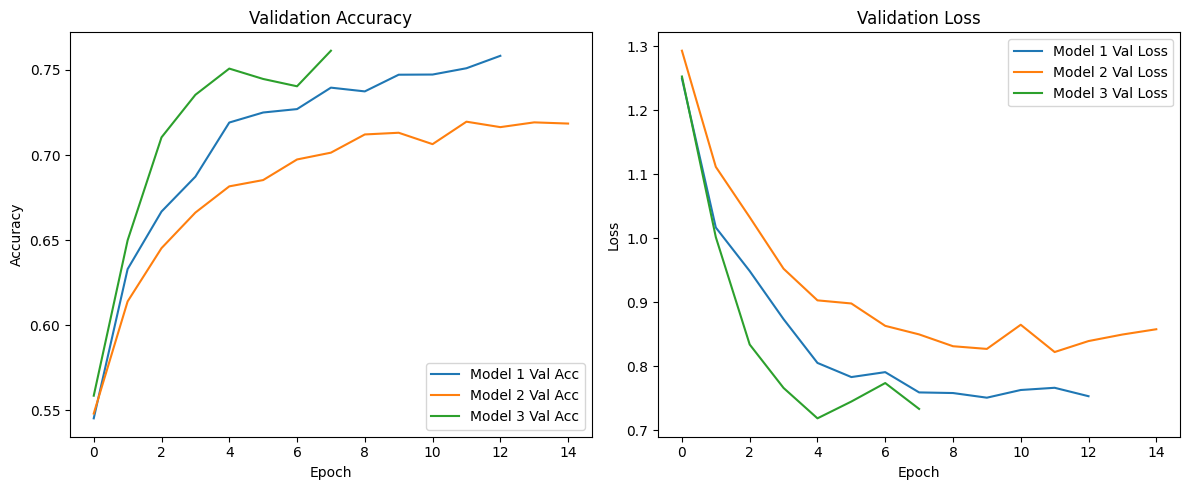

In [14]:
def compare_histories(histories, labels):
    plt.figure(figsize=(12,5))

    # Accuracy comparison
    plt.subplot(1,2,1)
    for history, label in zip(histories, labels):
        plt.plot(history.history['val_accuracy'], label=f'{label} Val Acc')
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss comparison
    plt.subplot(1,2,2)
    for history, label in zip(histories, labels):
        plt.plot(history.history['val_loss'], label=f'{label} Val Loss')
    plt.title('Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

compare_histories([history1, history2, history3], ['Model 1', 'Model 2', 'Model 3'])


In [15]:
# Get test accuracies
test_scores = {}
for model, label in zip([model1, model2, model3], ['Model 1', 'Model 2', 'Model 3']):
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    test_scores[label] = acc
    print(f'{label} Test Accuracy: {acc:.4f}')


Model 1 Test Accuracy: 0.7445
Model 2 Test Accuracy: 0.7130
Model 3 Test Accuracy: 0.7445


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


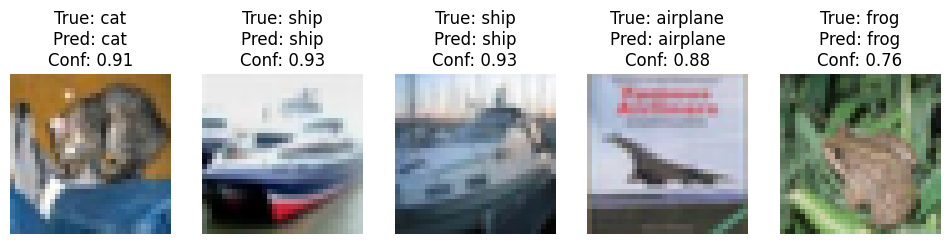

In [16]:
def show_predictions(model, X_test, y_test, class_names):
    y_probs = model.predict(X_test[:5])
    y_preds = np.argmax(y_probs, axis=1)
    y_true = np.argmax(y_test[:5], axis=1)

    plt.figure(figsize=(12,5))
    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.imshow(X_test[i])
        plt.axis('off')
        plt.title(f"True: {class_names[y_true[i]]}\nPred: {class_names[y_preds[i]]}\nConf: {y_probs[i][y_preds[i]]:.2f}")
    plt.show()

# Example usage
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
show_predictions(model3, X_test, y_test, class_names)
